In [1]:
import pandas as pd
import numpy as np


In [2]:
df = pd.read_csv('/content/dirty_customer_orders_500k_v2 (3).zip')

In [3]:
print("Shape:", df.shape)

Shape: (490000, 28)


In [4]:
df.head()

,customer_id,first_name,last_name,full_name,email,phone,age,gender,city,country,...,unit_price,total_amount,order_date,order_status,payment_method,is_premium,last_contact,satisfaction,referral_source,account_balance
0,CUST188579,Mona,Brown,Mona Brown,mona.brow@company.co,+20376333991,58.0,Male,Mansoura,USA,...,914.67,NaN,01-Jul-2019,Inactive,credit card,True,11-11-2023,10.0,Referral,876.95
1,CUST494116,Laila,Taylor,Laila Taylor,laila.tayl@mail.eg,369-366-1715,25.0,Female,Luxor,USA,...,1154.08,4616.32,2018/02/16,Pending,Credit Card,True,04/09/2018,3.0,Facebook,NaN
2,CUST069958,Nour,Miller,Nour Miller,nour.mill@hotmail.com,(193) 882-7999,NaN,Female,Tanta,UAE,...,792.93,3964.65,05-Aug-2020,Completed,Cash,True,2018-09-14,2.0,Ads,3313.09
3,CUST171996,Mohamed,Davis,"Davis, Mohamed",mohamed.davi@yahoo.com,169-628-9907,64.0,Male,Giza,USA,...,215.32,1507.24,19-Apr-2018,Pending,Credit Card,True,13/10/2019,1.0,Friend,13331.74
4,CUST123015,David,Nasser,NaN,david.nass@company.co,(230) 472-1412,63.0,Male,Port Said,USA,...,618.50,12370.00,01-13-2018,Completed,PayPal,Yes,18-Apr-2022,7.0,Google,14497.61


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 490000 entries, 0 to 489999
Data columns (total 28 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   customer_id        490000 non-null  object 
 1   first_name         490000 non-null  object 
 2   last_name          490000 non-null  object 
 3   full_name          450800 non-null  object 
 4   email              475461 non-null  object 
 5   phone              475220 non-null  object 
 6   age                480174 non-null  float64
 7   gender             460498 non-null  object 
 8   city               475547 non-null  object 
 9   country            470458 non-null  object 
 10  department         477698 non-null  object 
 11  job_title          474721 non-null  object 
 12  hire_date          490000 non-null  object 
 13  salary             480331 non-null  object 
 14  bonus              470761 non-null  float64
 15  performance_score  473755 non-null  float64
 16  pr

In [6]:
df.describe()

,age,bonus,performance_score,quantity,unit_price,total_amount,satisfaction
count,480174.000000,470761.000000,473755.000000,480067.000000,480275.000000,443313.000000,477792.000000
mean,44.611718,3915.236914,3.061337,12.743217,1239.311871,15619.352865,5.501185
std,19.209769,2355.494146,1.232705,7.411192,728.494501,14111.190587,2.969743
min,-5.000000,0.000000,1.000000,-2.000000,-50.000000,0.000000,0.000000
25%,31.000000,1872.750000,2.000000,6.000000,611.575000,3968.720000,3.000000
50%,44.000000,3908.390000,3.000000,13.000000,1240.560000,11542.500000,6.000000
75%,58.000000,5957.180000,4.100000,19.000000,1869.730000,24097.150000,8.000000
max,150.000000,7999.950000,6.500000,25.000000,2500.000000,67553.790000,11.000000


In [7]:
nulls = df.isnull().sum()

nulls_df = pd.DataFrame({
    'Null_Count': nulls,
    'Null_Percentage': round((nulls / len(df)) * 100, 2)
})

nulls_df.sort_values(by='Null_Count', ascending=False)

,Null_Count,Null_Percentage
total_amount,46687,9.53
full_name,39200,8.00
is_premium,30407,6.21
gender,29502,6.02
country,19542,3.99
bonus,19239,3.93
payment_method,17874,3.65
referral_source,17871,3.65
order_status,16404,3.35
account_balance,16401,3.35


In [8]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 3754


In [9]:
df['customer_id'].duplicated().sum()

np.int64(3754)

In [10]:
df[df['customer_id'].duplicated(keep=False)] \
.sort_values('customer_id') \
.head(20)

,customer_id,first_name,last_name,full_name,email,phone,age,gender,city,country,...,unit_price,total_amount,order_date,order_status,payment_method,is_premium,last_contact,satisfaction,referral_source,account_balance
23848,CUST000190,Isabella,Williams,NaN,isabella.will@mail.eg,(415) 588-1947,150.0,male,Cairo,Saudi Arabia,...,261.00,3132.00,2022-01-02,Cancelled,Visa,NaN,28/10/2023,8.0,FB,13817.44
332689,CUST000190,Isabella,Williams,NaN,isabella.will@mail.eg,(415) 588-1947,150.0,male,Cairo,Saudi Arabia,...,261.00,3132.00,2022-01-02,Cancelled,Visa,NaN,28/10/2023,8.0,FB,13817.44
73785,CUST000227,Ali,Miller,"Miller, Ali",ali.mill@yahoo.com,+20760710681,56.0,female,Aswan,UAE,...,NaN,0.00,13-Aug-2023,Inactive,Cash,True,2023/09/17,4.0,Google,10581.51
206584,CUST000227,Ali,Miller,"Miller, Ali",ali.mill@yahoo.com,+20760710681,56.0,female,Aswan,UAE,...,NaN,0.00,13-Aug-2023,Inactive,Cash,True,2023/09/17,4.0,Google,10581.51
229081,CUST000267,Hana,Mostafa,"Mostafa, Hana",hana.most@gmail.com,0124438381,26.0,Male,Cairo,USA,...,1032.57,24781.68,2022/08/15,Completed,Visa,True,2020-01-05,6.0,Website,14114.49
908,CUST000267,Hana,Mostafa,"Mostafa, Hana",hana.most@gmail.com,0124438381,26.0,Male,Cairo,USA,...,1032.57,24781.68,2022/08/15,Completed,Visa,True,2020-01-05,6.0,Website,14114.49
380193,CUST000454,John,Said,"Said, John",john.said@outlook.com,+20127891556,-5.0,Female,Port Said,USA,...,220.08,4181.52,2024/05/12,Pending,PayPal,True,10-24-2024,3.0,Website,183.04
403256,CUST000454,John,Said,"Said, John",john.said@outlook.com,+20127891556,-5.0,Female,Port Said,USA,...,220.08,4181.52,2024/05/12,Pending,PayPal,True,10-24-2024,3.0,Website,183.04
248544,CUST000589,Olivia,Jones,Olivia Jones,olivia.jone@gmail.com,+20923494536,61.0,Male,Tanta,UAE,...,972.80,24320.00,2025-06-28,Completed,PayPal,False,2019-09-26,9.0,NaN,14881.65
267951,CUST000589,Olivia,Jones,Olivia Jones,olivia.jone@gmail.com,+20923494536,61.0,Male,Tanta,UAE,...,972.80,24320.00,2025-06-28,Completed,PayPal,False,2019-09-26,9.0,NaN,14881.65


In [11]:
df = df.drop_duplicates()

In [12]:
print("Rows after cleaning:", df.shape[0])
print("Remaining duplicates:", df.duplicated().sum())

Rows after cleaning: 486246
Remaining duplicates: 0


In [13]:
df.columns.tolist()

['customer_id',
 'first_name',
 'last_name',
 'full_name',
 'email',
 'phone',
 'age',
 'gender',
 'city',
 'country',
 'department',
 'job_title',
 'hire_date',
 'salary',
 'bonus',
 'performance_score',
 'product_purchased',
 'quantity',
 'unit_price',
 'total_amount',
 'order_date',
 'order_status',
 'payment_method',
 'is_premium',
 'last_contact',
 'satisfaction',
 'referral_source',
 'account_balance']

In [14]:
df.sample(10)

,customer_id,first_name,last_name,full_name,email,phone,age,gender,city,country,...,unit_price,total_amount,order_date,order_status,payment_method,is_premium,last_contact,satisfaction,referral_source,account_balance
262415,CUST041897,Robert,Ibrahim,Robert Ibrahim,robert.ibra@hotmail.com,310-281-6254,52.0,Male,Mansoura,Saudi Arabia,...,1242.29,22361.22,2024-03-28,Completed,PayPal,False,2023-01-01,3.0,Referral,14241.34
433522,CUST007410,Salma,Ibrahim,NaN,salma.ibra@company.co,+20824708166,31.0,M,Ismailia,UAE,...,570.57,3993.99,04-02-2025,Pending,Cash,True,06-17-2021,10.0,Website,7180.96
419738,CUST127841,James,Garcia,James Garcia,james.garc@hotmail.com,+20442257597,18.0,Female,Aswan,UAE,...,541.24,12989.76,2023/04/06,Cancelled,Cash,False,22-Jul-2024,9.0,Referral,6671.63
470088,CUST495659,Salma,Miller,Salma Miller,salma.mill@company.co,593-505-9263,-5.0,Female,Giza,Egypt,...,1197.58,19161.28,2024/09/11,cancel,Cash,True,2019-02-01,4.0,Website,10986.03
468955,CUST036271,Dina,Wilson,Dina Wilson,dina.wils@hotmail.com,+20211393963,32.0,Female,Ismailia,EG,...,134.35,1477.85,2024/04/02,Active,Cash,NaN,2023/08/25,1.0,Google,10420.48
320220,CUST269911,Hana,Ibrahim,Hana Ibrahim,hana.ibra@gmail.com,627-731-1104,49.0,Female,Mansoura,Saudi Arabia,...,892.91,8036.19,2024-11-28,Cancelled,CASH,False,2025-03-12,7.0,Ads,11720.47
449952,CUST111609,Dina,Jones,Dina Jones,dina.jone@yahoo.com,(479) 727-5439,40.0,Male,Alexandria,NaN,...,836.67,3346.68,2018/06/01,Cancelled,Visa,True,15-May-2025,3.0,Referral,6599.14
396240,CUST297547,Khaled,Mostafa,"Mostafa, Khaled",khaled.most@outlook.com,+20297928746,60.0,Female,Cairo,USA,...,1648.09,0.00,2022-11-07,Cancelled,Visa,True,11-20-2021,9.0,NaN,12434.78
36952,CUST437251,Hana,Mostafa,Hana Mostafa,hana.most@gmail.com,(711) 536-4081,NaN,Male,Port Said,USA,...,422.42,844.84,09-Apr-2020,Active,CASH,False,2022/02/25,6.0,Referral,13084.5
107901,CUST363276,Khaled,Taylor,"Taylor, Khaled",khaled.tayl@hotmail.com,0518012893,52.0,Female,Giza,UAE,...,536.67,5903.37,2019/06/11,Pending,Credit Card,True,03-06-2021,1.0,Ads,3584.87


In [15]:
nulls = df.isnull().sum().sort_values(ascending=False)
nulls[nulls > 0]

,0
total_amount,46369
full_name,38904
is_premium,30206
gender,29279
country,19404
bonus,19096
payment_method,17743
referral_source,17731
order_status,16279
account_balance,16263


In [16]:
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip().str.replace(r'\s+', ' ', regex=True)

In [17]:
df['full_name'] = df['full_name'].fillna(
    df['first_name'] + ' ' + df['last_name']
)


df['full_name'] = (
    df['full_name']
    .str.replace(r'\s*,\s*', ' ', regex=True)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
    .str.title()
)

In [18]:
print(df['full_name'].isnull().sum())

0


In [19]:
df[['first_name','last_name','full_name']].head(10)

,first_name,last_name,full_name
0,Mona,Brown,Mona Brown
1,Laila,Taylor,Laila Taylor
2,Nour,Miller,Nour Miller
3,Mohamed,Davis,Davis Mohamed
4,David,Nasser,David Nasser
5,Khaled,Smith,Smith Khaled
6,Mohamed,Smith,Mohamed Smith
7,Aya,Miller,Aya Miller
8,Dina,Kamal,Dina Kamal
9,Aya,Taylor,Aya Taylor


In [20]:
gmail_count = df['email'].str.contains('@gmail.com', na=False).sum()

print("Gmail Count:", gmail_count)
print("Percentage:", round(gmail_count / len(df) * 100, 2), "%")

Gmail Count: 81989
Percentage: 16.86 %


In [21]:
df['email'] = df['email'].apply(
    lambda x: 'Unknown'
    if pd.isna(x) or (isinstance(x, str) and x.startswith('@'))
    else x
)

In [22]:
print("Nulls:", df['email'].isnull().sum())

Nulls: 0


In [23]:
df['email'].sample(20)

,email
401881,james.mill@mail.eg
56281,tarek.wils@gmail.com
67852,sara.tayl@mail.eg
349980,robert.mahm@outlook.com
229203,fatma.tayl@gmail.com
359289,sophia.nass@gmail.com
83579,aya.ibra@outlook.com
146297,sophia.said@company.co
479504,omar.said@gmail.com
297847,omar.wils@hotmail.com


In [24]:
df['phone'] = (
    df['phone']
    .fillna('Unknown')
    .astype(str)
    .str.replace(r'[^0-9]', '', regex=True)
)

df.loc[df['phone'] == '', 'phone'] = 'Unknown'

In [25]:
print("Nulls:", df['phone'].isnull().sum())
print("Unknown:", (df['phone'] == 'Not Provided').sum())

Nulls: 0
Unknown: 0


In [26]:
df['phone'].sample(20)

,phone
27626,0655222218
214642,9499291204
134950,9336548978
247107,9286763100
330909,7328276325
223419,20437405446
415121,0864696704
160071,6829926572
311248,20754157167
398080,8248306385


In [27]:
df['age'].describe()

,age
count,476504.000000
mean,44.609592
std,19.205086
min,-5.000000
25%,31.000000
50%,44.000000
75%,58.000000
max,150.000000


In [28]:
print("Nulls:", df['age'].isnull().sum())

Nulls: 9742


In [29]:
df[df['age'] < 18]['age'].count()

np.int64(4916)

In [30]:
df[df['age'] > 100]['age'].count()

np.int64(4881)

In [31]:
df = df[(df['age'].isna()) | ((df['age'] >= 18) & (df['age'] <= 100))]

In [32]:
print(df['age'].isna().sum())
print(df['age'].min())
print(df['age'].max())

9742
18.0
70.0


In [33]:
df['age'] = df['age'].fillna(df['age'].median())

In [34]:
df['age'] = df['age'].astype(int)

In [35]:
df['age'].describe()
df['age'].isna().sum()

np.int64(0)

In [36]:
df['gender'] = df['gender'].replace({
    'M': 'Male',
    'male': 'Male',
    'F': 'Female',
    'female': 'Female',
    'Other': 'Unknown',
    'unknown' : 'Unknown'
})

df['gender'] = df['gender'].fillna('Unknown')

In [37]:
df['gender'].value_counts(dropna=False)

,count
gender,
Female,210172
Male,209388
Unknown,56889


In [38]:
df['city'] = df['city'].replace({
    'ALEX': 'Alexandria'
})

In [39]:
df['city'].value_counts().head(20)

,count
city,
Mansoura,50252
Alexandria,49770
Tanta,43086
Ismailia,42812
Aswan,42718
Suez,42717
Giza,42566
Cairo,42518
Port Said,42449


In [40]:
df['city'].unique()

array(['Mansoura', 'Luxor', 'Tanta', 'Giza', 'Port Said', 'Suez', 'giza',
       'cairo', 'Ismailia', 'Alexandria', 'Cairo', nan, 'Unknown',
       'Aswan'], dtype=object)

In [41]:
df['city'] = df['city'].str.strip()

In [42]:
df['city'].unique()

array(['Mansoura', 'Luxor', 'Tanta', 'Giza', 'Port Said', 'Suez', 'giza',
       'cairo', 'Ismailia', 'Alexandria', 'Cairo', nan, 'Unknown',
       'Aswan'], dtype=object)

In [43]:
df['city'].isnull().sum()

np.int64(14060)

In [44]:
print("Nulls:", df['city'].isnull().sum())
print("Unknown:", (df['city'] == 'Unknown').sum())

Nulls: 14060
Unknown: 7137


In [45]:
df['city'] = (
    df['city']
    .fillna('Unknown')
    .str.strip()
    .str.title()
)

In [46]:
df['city'].unique()

array(['Mansoura', 'Luxor', 'Tanta', 'Giza', 'Port Said', 'Suez', 'Cairo',
       'Ismailia', 'Alexandria', 'Unknown', 'Aswan'], dtype=object)

In [47]:
df['country'].isnull().sum()

np.int64(18989)

In [48]:
df['country'] = df['country'].str.strip()

In [49]:
df['country'] = df['country'].replace({
    'EG': 'Egypt',
    'egypt': 'Egypt',
    'UAE': 'United Arab Emirates',
    'USA': 'United States'
})

df['country'] = df['country'].fillna('Unknown')

In [50]:
df['country'].value_counts(dropna=False)

,count
country,
Egypt,132842
United Arab Emirates,105298
United States,105057
Saudi Arabia,104770
Unknown,28482


In [51]:
df['department'].isnull().sum()

np.int64(11966)

In [52]:
df['department'].value_counts(dropna=False)

,count
department,
R&D,54019
Customer Support,53752
Marketing,53697
Operations,53571
Sales,53546
IT,53421
Finance,53385
HR,53354
NaN,11966


In [53]:
df['department'] = df['department'].fillna('Unknown')

In [54]:
df['department'] = df['department'].str.strip().str.upper()

In [55]:
df['department'].value_counts(dropna=False)

,count
department,
MARKETING,59651
SALES,59533
IT,59381
R&D,54019
CUSTOMER SUPPORT,53752
OPERATIONS,53571
FINANCE,53385
HR,53354
UNKNOWN,11966


In [56]:
df['job_title'].isnull().sum()

np.int64(14864)

In [57]:
df['job_title'].value_counts(dropna=False)

,count
job_title,
Engineer,62024
Sales Rep,61945
Developer,61884
Accountant,61805
Analyst,61754
Senior Manager,61592
Manager,61563
NaN,14864
Dev,7397


In [58]:
df['job_title'] = df['job_title'].replace({
    'manager': 'Manager',
    'ANALYST': 'Analyst',
    'Sales Rep': 'Sales Representative'
})

In [59]:
df['job_title'].unique()


array(['Developer', 'Senior Manager', 'Engineer', 'Sales Representative',
       'Analyst', 'Accountant', 'Manager', nan, 'Dev'], dtype=object)

In [60]:
df['job_title'] = df['job_title'].fillna('Unknown')

In [61]:
df['hire_date'] = pd.to_datetime(df['hire_date'], format='mixed', errors='coerce')
df['hire_date'].isna().sum()

np.int64(0)

In [62]:
df['hire_date'].dtype

dtype('<M8[ns]')

In [63]:
df['hire_date'] = df['hire_date'].dt.strftime('%Y-%m-%d')

In [64]:
print(df['hire_date'].dtype)

object


In [65]:
df['hire_date'] = pd.to_datetime(df['hire_date'], format='mixed', errors='coerce')

print(df['hire_date'].dtype)
df.info()

datetime64[ns]
<class 'pandas.core.frame.DataFrame'>
Index: 476449 entries, 0 to 489999
Data columns (total 28 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   customer_id        476449 non-null  object        
 1   first_name         476449 non-null  object        
 2   last_name          476449 non-null  object        
 3   full_name          476449 non-null  object        
 4   email              476449 non-null  object        
 5   phone              476449 non-null  object        
 6   age                476449 non-null  int64         
 7   gender             476449 non-null  object        
 8   city               476449 non-null  object        
 9   country            476449 non-null  object        
 10  department         476449 non-null  object        
 11  job_title          476449 non-null  object        
 12  hire_date          476449 non-null  datetime64[ns]
 13  salary             467024 non-null

In [66]:
df['hire_date'].head()

,hire_date
0,2018-04-21
1,2022-05-15
2,2025-07-18
3,2025-01-25
4,2024-01-22


In [67]:
df['salary'] = df['salary'].astype(str).str.strip()

In [68]:
df['salary'].unique()[:20]

array(['45279', '46392 EGP', '40876', '$45876', 'confidential', '38,349',
       '$12995', '13740', '47,687', '20705', '50147 EGP', '$75929',
       '48867 EGP', '70897', '29597 EGP', '8,745', '72381 EGP',
       '16093 EGP', '73,754', '$17634'], dtype=object)

In [69]:
df['salary'] = (
    df['salary']
    .astype(str)
    .str.replace('EGP', '', regex=False)
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
)

In [70]:
df['salary'] = pd.to_numeric(df['salary'], errors='coerce')

In [71]:
df['salary'].isna().sum()

np.int64(14229)

In [72]:
df['salary'] = df['salary'].fillna(df['salary'].mean())

In [73]:
df['salary'].isna().sum()

np.int64(0)

In [74]:
df['salary'] = df['salary'].astype(int)

In [75]:
df['salary'].describe()

,salary
count,476449.000000
mean,41527.784432
std,21887.190025
min,3000.000000
25%,22862.000000
50%,41527.000000
75%,60166.000000
max,80000.000000


In [76]:
df['salary'].dtype

dtype('int64')

In [77]:
df['bonus'].head()
df['bonus'].dtype
df['bonus'].isna().sum()

np.int64(18716)

In [78]:
df['bonus'].describe()


,bonus
count,457733.000000
mean,3915.865050
std,2355.617621
min,0.000000
25%,1873.680000
50%,3909.740000
75%,5957.950000
max,7999.950000


In [79]:
df['bonus'] = df['bonus'].fillna(df['bonus'].mean())

In [80]:
df['bonus'].isna().sum()

np.int64(0)

In [81]:
df['bonus'] = df['bonus'].astype(int)

In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 476449 entries, 0 to 489999
Data columns (total 28 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   customer_id        476449 non-null  object        
 1   first_name         476449 non-null  object        
 2   last_name          476449 non-null  object        
 3   full_name          476449 non-null  object        
 4   email              476449 non-null  object        
 5   phone              476449 non-null  object        
 6   age                476449 non-null  int64         
 7   gender             476449 non-null  object        
 8   city               476449 non-null  object        
 9   country            476449 non-null  object        
 10  department         476449 non-null  object        
 11  job_title          476449 non-null  object        
 12  hire_date          476449 non-null  datetime64[ns]
 13  salary             476449 non-null  int64        

In [83]:
df['performance_score'].isna().sum()

np.int64(15802)

In [84]:
df['performance_score'].describe()

,performance_score
count,460647.000000
mean,3.061218
std,1.232755
min,1.000000
25%,2.000000
50%,3.000000
75%,4.100000
max,6.500000


In [85]:
df['performance_score'].unique()

array([3.7, 2.1, 1.6, 2.7, 4.1, 4. , 4.7, 3.2, 1.9, 2.6, 4.3, 2.4, 1.2,
       1.4, 3.5, 4.9, 2.9, 1.3, nan, 4.4, 3.8, 2. , 3. , 3.3, 2.8, 1.5,
       1.8, 4.6, 2.5, 3.4, 5. , 2.3, 4.5, 1.7, 3.9, 4.8, 3.1, 3.6, 4.2,
       1. , 1.1, 6.5, 2.2])

In [86]:
(df['performance_score'] > 5).sum()

np.int64(7877)

In [87]:
df = df[
    (df['performance_score'].isna()) |
    (df['performance_score'] <= 5)
]

In [88]:
(df['performance_score'] > 5).sum()

np.int64(0)

In [89]:
df['performance_score'] = df['performance_score'].fillna(
    df['performance_score'].median()
)

In [90]:
df['performance_score'].isna().sum()

np.int64(0)

In [91]:
df['product_purchased'] = df['product_purchased'].str.title()

In [92]:
df['product_purchased'].unique()[:20]

array(['Tablet', 'Laptop', 'Camera', 'Keyboard', 'Headphones', 'Mouse',
       'Monitor', 'Smart Watch', 'Phone', nan, 'Unknown'], dtype=object)

In [93]:
df['product_purchased'].isna().sum()

np.int64(6424)

In [94]:
df['product_purchased'] = df['product_purchased'].fillna('Unknown')

In [95]:
df['product_purchased'].isna().sum()

np.int64(0)

In [96]:
df['quantity'].describe()

,quantity
count,459062.000000
mean,12.741129
std,7.411294
min,-2.000000
25%,6.000000
50%,13.000000
75%,19.000000
max,25.000000


In [97]:
(df['quantity'] < 0).sum()

np.int64(4693)

In [98]:
(df['quantity'] < 0).sum()

np.int64(4693)

In [99]:
df = df[(df['quantity'].isna()) | (df['quantity'] >= 0)]

In [100]:
df['quantity'].isna().sum()

np.int64(9510)

In [101]:
df['quantity'] = df['quantity'].fillna(df['quantity'].median())

In [102]:
df['quantity'] = df['quantity'].astype(int)

In [103]:
df['quantity'].isna().sum()
df['quantity'].dtype
df['quantity'].describe()

,quantity
count,463879.000000
mean,12.895570
std,7.220528
min,0.000000
25%,7.000000
50%,13.000000
75%,19.000000
max,25.000000


In [104]:
(df['unit_price'] < 0).sum()

np.int64(4666)

In [105]:
df['unit_price'].isna().sum()

np.int64(9168)

In [106]:
df = df[(df['unit_price'] >= 0) | (df['unit_price'].isna())]

In [107]:
df['unit_price'] = df['unit_price'].fillna(df['unit_price'].median())

In [108]:
df['unit_price'].isna().sum()
df['unit_price'].min()

0.0

In [109]:
(df['total_amount'] < 0).sum()

np.int64(0)

In [110]:
mask = df['total_amount'].isna()

df.loc[mask, 'total_amount'] = (
    df.loc[mask, 'quantity'] * df.loc[mask, 'unit_price']
)

In [111]:
df['total_amount'].isna().sum()

np.int64(0)

In [112]:
wrong = (
    abs(df['quantity'] * df['unit_price'] - df['total_amount']) > 0.01
)

wrong.sum()

np.int64(50754)

In [113]:
wrong = abs(df['quantity'] * df['unit_price'] - df['total_amount']) > 0.01

wrong.sum() / len(df) * 100

np.float64(11.052387454187926)

In [114]:
mask = abs(df['quantity'] * df['unit_price'] - df['total_amount']) > 0.01

df.loc[mask, 'total_amount'] = (
    df.loc[mask, 'quantity'] * df.loc[mask, 'unit_price']
)

In [115]:
wrong = abs(df['quantity'] * df['unit_price'] - df['total_amount']) > 0.01

wrong.sum()

np.int64(0)

In [116]:
df['hire_date'] = pd.to_datetime(df['hire_date'], format='mixed', errors='coerce')
df['hire_date'].isna().sum()

np.int64(0)

In [117]:
df['hire_date'].dtype

dtype('<M8[ns]')

In [118]:
print(df['hire_date'].dtype)

datetime64[ns]


In [119]:
df['hire_date'].head()


,hire_date
0,2018-04-21
1,2022-05-15
2,2025-07-18
3,2025-01-25
4,2024-01-22


In [120]:
df['order_status'].value_counts(dropna=False)

,count
order_status,
Completed,81687
Cancelled,81238
Active,80979
Inactive,80788
Pending,80766
NaN,15404
pending,7743
cancel,7712
INACTIVE,7700


In [121]:
df['order_status'] = df['order_status'].replace({
    'Complete': 'Completed',
    'cancel': 'Cancelled',
    'active': 'Active',
    'pending': 'Pending',
    'INACTIVE': 'Inactive',
    'cancelled': 'Cancelled'
})

In [122]:
df['order_status'].value_counts(dropna=False)

,count
order_status,
Completed,89338
Cancelled,88950
Active,88524
Pending,88509
Inactive,88488
NaN,15404


In [123]:
df['order_status'] = df['order_status'].fillna('Unknown')

In [124]:
df['order_status'].value_counts(dropna=False)

,count
order_status,
Completed,89338
Cancelled,88950
Active,88524
Pending,88509
Inactive,88488
Unknown,15404


In [125]:
df['payment_method'].value_counts(dropna=False)

,count
payment_method,
Bank Transfer,69746
MasterCard,69618
PayPal,69549
Credit Card,69533
Cash,69509
Visa,69462
NaN,16759
credit card,8373
unknown,8336


In [126]:
df['order_status'] = df['order_status'].replace({
    'credit card': 'Credit Card',
    'CASH': 'Cash',
    'Cash': 'Cash',
    'cash': 'Cash',
    'Credit Card': 'Credit Card'
})


In [127]:
df['payment_method'].value_counts(dropna=False)

,count
payment_method,
Bank Transfer,69746
MasterCard,69618
PayPal,69549
Credit Card,69533
Cash,69509
Visa,69462
NaN,16759
credit card,8373
unknown,8336


In [128]:
df['payment_method'] = (
    df['payment_method']
    .str.strip()
    .replace({
        'credit card': 'Credit Card',
        'unknown': 'Unknown',
        'CASH': 'Cash'
    })
    .fillna('Unknown')
)

In [129]:
df['payment_method'].value_counts(dropna=False)

,count
payment_method,
Credit Card,77906
Cash,77837
Bank Transfer,69746
MasterCard,69618
PayPal,69549
Visa,69462
Unknown,25095


In [130]:
df.rename(columns={'is_premium': 'premium_customer'}, inplace=True)

In [131]:
df['premium_customer'].value_counts(dropna=False)

,count
premium_customer,
False,186733
True,186484
NaN,28618
0,14450
1,14437
Yes,14261
No,14230


In [132]:
df['premium_customer'] = (
    df['premium_customer']
    .replace({
        1: True,
        '1': True,
        'YES': True,
        'Yes': True,
        'TRUE': True,
        'True': True,

        0: False,
        '0': False,
        'NO': False,
        'No': False,
        'FALSE': False,
        'False': False
    })
)

In [133]:
df['premium_customer'].value_counts(dropna=False)

,count
premium_customer,
False,215413
True,215182
NaN,28618


In [134]:
df['premium_customer'] = (
    df['premium_customer']
    .astype('object')
    .fillna('Unknown')
)

In [135]:
df['premium_customer'].value_counts(dropna=False)

,count
premium_customer,
False,215413
True,215182
Unknown,28618


In [136]:
df['last_contact'] = pd.to_datetime(
    df['last_contact'],
    errors='coerce',
    format='mixed'
)

In [137]:
df['last_contact'].dtype

dtype('<M8[ns]')

In [138]:
(df['satisfaction'] > 10).sum()

np.int64(5771)

In [139]:
df['satisfaction'].isna().sum()

np.int64(11433)

In [140]:
df = df[(df['satisfaction'].isna()) | ((df['satisfaction'] >= 0) & (df['satisfaction'] <= 10))]

In [141]:
(df['satisfaction'] > 10).sum()

np.int64(0)

In [142]:
df['satisfaction'].median()

5.0

In [143]:
df['satisfaction'].dtype

dtype('float64')

In [144]:
df['satisfaction'].unique()

array([10.,  3.,  2.,  1.,  7.,  9.,  4.,  0.,  8.,  6.,  5., nan])

In [145]:
df['satisfaction'] = df['satisfaction'].fillna(df['satisfaction'].median())

In [146]:
df['satisfaction'] = df['satisfaction'].astype(int)

In [147]:
df['satisfaction'].dtype

dtype('int64')

In [148]:
df['satisfaction'].isna().sum()

np.int64(0)

In [149]:
df['referral_source'].value_counts(dropna=False)

,count
referral_source,
Google,69198
Ads,68949
Referral,68818
Website,68387
Friend,68318
Facebook,68273
NaN,16544
google,8385
FB,8348


In [150]:
df['referral_source'] = df['referral_source'].str.strip().str.title()

In [151]:
df['referral_source'] = df['referral_source'].fillna('Unknown')

In [152]:
df['referral_source'].value_counts(dropna=False)

,count
referral_source,
Google,77583
Ads,68949
Referral,68818
Website,68387
Friend,68318
Facebook,68273
Unknown,24766
Fb,8348


In [153]:
df['account_balance'].isna().sum()

np.int64(15142)

In [154]:
df['account_balance'] = pd.to_numeric(
    df['account_balance'],
    errors='coerce'
)

In [155]:
df['account_balance'].dtype

dtype('float64')

In [156]:
(df['account_balance'] < 0).sum()

np.int64(13861)

In [157]:
Q1 = df['account_balance'].quantile(0.25)
Q3 = df['account_balance'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df['account_balance'] < lower) |
    (df['account_balance'] > upper)
]

print("Number of outliers:", len(outliers))
print("Lower bound:", lower)
print("Upper bound:", upper)

Number of outliers: 0
Lower bound: -8234.7
Upper bound: 22764.02


In [158]:
df['account_balance'] = df['account_balance'].fillna(
    df['account_balance'].mean()
)

In [159]:
df['account_balance'].isna().sum()

np.int64(0)

In [160]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 453442 entries, 0 to 489999
Data columns (total 28 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   customer_id        453442 non-null  object        
 1   first_name         453442 non-null  object        
 2   last_name          453442 non-null  object        
 3   full_name          453442 non-null  object        
 4   email              453442 non-null  object        
 5   phone              453442 non-null  object        
 6   age                453442 non-null  int64         
 7   gender             453442 non-null  object        
 8   city               453442 non-null  object        
 9   country            453442 non-null  object        
 10  department         453442 non-null  object        
 11  job_title          453442 non-null  object        
 12  hire_date          453442 non-null  datetime64[ns]
 13  salary             453442 non-null  int64        

In [161]:
df['order_date'].dtype

dtype('O')

In [162]:
print(df['order_date'].dtype)

object


In [163]:
df['order_date'] = pd.to_datetime(
    df['order_date'],
    errors='coerce',
    format='mixed'
)

In [164]:
print(df['order_date'].dtype)

datetime64[ns]


In [165]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 453442 entries, 0 to 489999
Data columns (total 28 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   customer_id        453442 non-null  object        
 1   first_name         453442 non-null  object        
 2   last_name          453442 non-null  object        
 3   full_name          453442 non-null  object        
 4   email              453442 non-null  object        
 5   phone              453442 non-null  object        
 6   age                453442 non-null  int64         
 7   gender             453442 non-null  object        
 8   city               453442 non-null  object        
 9   country            453442 non-null  object        
 10  department         453442 non-null  object        
 11  job_title          453442 non-null  object        
 12  hire_date          453442 non-null  datetime64[ns]
 13  salary             453442 non-null  int64        

In [ ]:
######## FEATURE ENGINEERING ########

In [166]:
df['salary_category'] = pd.qcut(
    df['salary'],
    q=4,
    labels=['Low','Medium','High','Very High']
)

In [167]:
df['balance_category'] = pd.cut(
    df['account_balance'],
    bins=[-500,0,1000,5000,15000],
    labels=['Debt','Low','Medium','High']
)

In [168]:
df['balance_category'] = pd.cut(
    df['account_balance'],
    bins=[-500,0,1000,5000,15000],
    labels=['Debt','Low','Medium','High']
)

In [169]:
df['satisfaction_level'] = pd.cut(
    df['satisfaction'],
    bins=[0,3,7,10],
    labels=['Low','Medium','High']
)

In [195]:
df['satisfaction_level'] = pd.cut(
    df['satisfaction'],
    bins=[0,3,7,10],
    labels=['Low','Medium','High'],
    include_lowest=True
)

In [170]:
df['order_year'] = df['order_date'].dt.year

df['order_month'] = df['order_date'].dt.month_name()

df['order_quarter'] = df['order_date'].dt.quarter

In [171]:
df['tenure_years'] = (
    pd.Timestamp.today() - df['hire_date']
).dt.days / 365

In [191]:
df[['balance_category',
    'satisfaction_level',
    'order_year',
    'order_month']].isna().sum()

,0
balance_category,0
satisfaction_level,5736
order_year,0
order_month,0


In [180]:
######### EDA ##########

In [172]:
df.describe()

,age,hire_date,salary,bonus,performance_score,quantity,unit_price,total_amount,order_date,last_contact,satisfaction,account_balance,order_year,order_quarter,tenure_years
count,453442.000000,453442,453442.000000,453442.000000,453442.000000,453442.000000,453442.000000,453442.000000,453442,453442,453442.000000,453442.000000,453442.000000,453442.000000,453442.000000
mean,44.037800,2021-12-29 06:16:03.859544832,41528.365623,3914.491803,3.001646,12.893115,1252.643231,16155.501124,2021-12-29 03:32:23.105402368,2021-12-29 13:39:39.416110592,5.418135,7260.342248,2021.498672,2.501508,4.585586
min,18.000000,2018-01-01 00:00:00,3000.000000,0.000000,1.000000,0.000000,0.000000,0.000000,2018-01-01 00:00:00,2018-01-01 00:00:00,0.000000,-499.980000,2018.000000,1.000000,0.586301
25%,31.000000,2020-01-01 00:00:00,22857.000000,1954.000000,2.000000,7.000000,643.980000,4650.740000,2019-12-25 00:00:00,2019-12-27 00:00:00,3.000000,3595.360000,2019.000000,2.000000,2.575342
50%,44.000000,2021-12-26 00:00:00,41527.000000,3915.000000,3.000000,13.000000,1253.170000,12364.280000,2021-12-28 00:00:00,2022-01-02 00:00:00,5.000000,7260.342248,2021.000000,3.000000,4.594521
75%,57.000000,2024-01-02 00:00:00,60174.750000,5871.000000,4.000000,19.000000,1862.847500,24609.582500,2024-01-03 00:00:00,2023-12-27 00:00:00,8.000000,10934.390000,2024.000000,3.000000,6.580822
max,70.000000,2025-12-28 00:00:00,80000.000000,7999.000000,5.000000,25.000000,2500.000000,62492.750000,2025-12-28 00:00:00,2025-12-28 00:00:00,10.000000,14999.980000,2025.000000,4.000000,8.580822
std,15.145826,NaN,21891.892377,2308.670346,1.136508,7.221317,712.968086,13882.207531,NaN,NaN,2.884343,4357.440302,2.293982,1.117121,2.312666


In [173]:
df.select_dtypes(include='number').corr()

,age,salary,bonus,performance_score,quantity,unit_price,total_amount,satisfaction,account_balance,order_year,order_quarter,tenure_years
age,1.000000,0.000438,-0.000642,0.002114,-0.000358,-0.001787,-0.000891,-0.002092,-0.001538,0.001647,-0.000989,-0.000607
salary,0.000438,1.000000,0.001405,-0.000834,-0.000667,0.000054,0.000268,0.000909,-0.000477,0.001063,0.000221,-0.002112
bonus,-0.000642,0.001405,1.000000,-0.000852,0.001538,0.000622,0.001826,-0.001089,-0.001065,-0.001091,0.001425,0.003199
performance_score,0.002114,-0.000834,-0.000852,1.000000,0.000325,0.000196,-0.000091,0.001088,0.002456,-0.000187,-0.003286,0.000215
quantity,-0.000358,-0.000667,0.001538,0.000325,1.000000,0.000976,0.651780,-0.000580,-0.001232,-0.003239,-0.000437,0.000930
unit_price,-0.001787,0.000054,0.000622,0.000196,0.000976,1.000000,0.662150,-0.000091,-0.004762,0.000359,-0.000658,0.000901
total_amount,-0.000891,0.000268,0.001826,-0.000091,0.651780,0.662150,1.000000,0.000231,-0.004121,-0.001373,-0.000371,0.001236
satisfaction,-0.002092,0.000909,-0.001089,0.001088,-0.000580,-0.000091,0.000231,1.000000,0.001283,-0.001162,0.001105,0.001376
account_balance,-0.001538,-0.000477,-0.001065,0.002456,-0.001232,-0.004762,-0.004121,0.001283,1.000000,-0.001451,-0.001234,-0.000213
order_year,0.001647,0.001063,-0.001091,-0.000187,-0.003239,0.000359,-0.001373,-0.001162,-0.001451,1.000000,0.001549,0.001428


In [175]:
df['satisfaction'].value_counts().sort_index()

,count
satisfaction,
0,5736
1,43567
2,43713
3,43543
4,43638
5,55128
6,43594
7,43684
8,43681


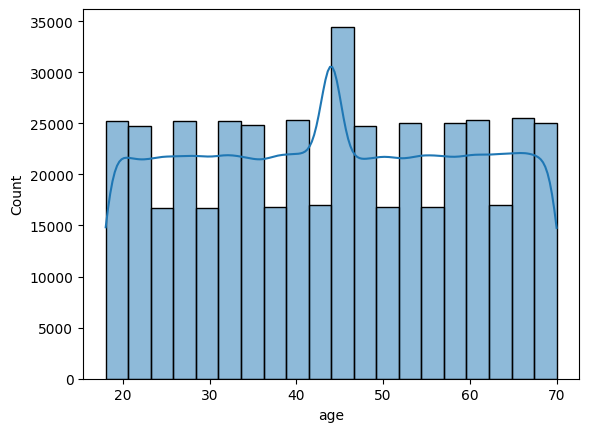

In [181]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['age'], bins=20, kde=True)
plt.show()

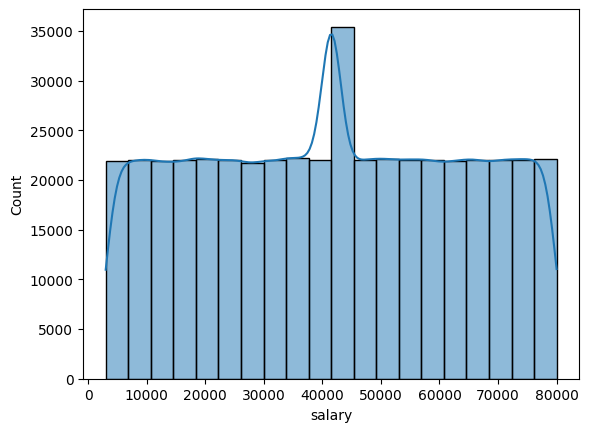

In [182]:
sns.histplot(df['salary'], bins=20, kde=True)
plt.show()

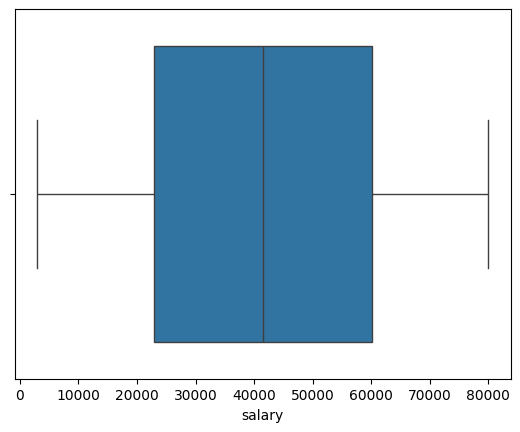

In [183]:
sns.boxplot(x=df['salary'])
plt.show()

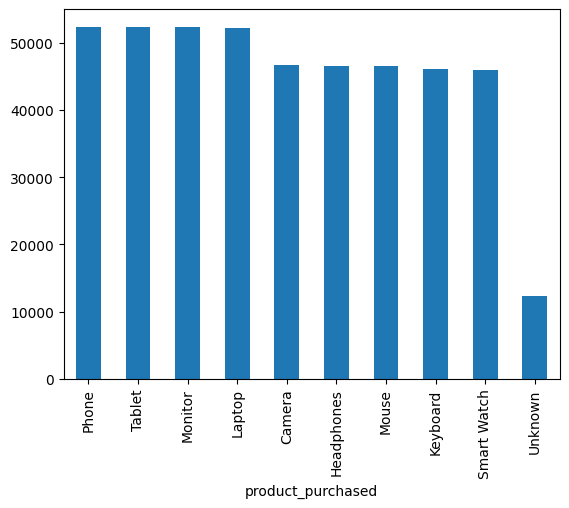

In [184]:
df['product_purchased'].value_counts().head(10).plot(kind='bar')
plt.show()

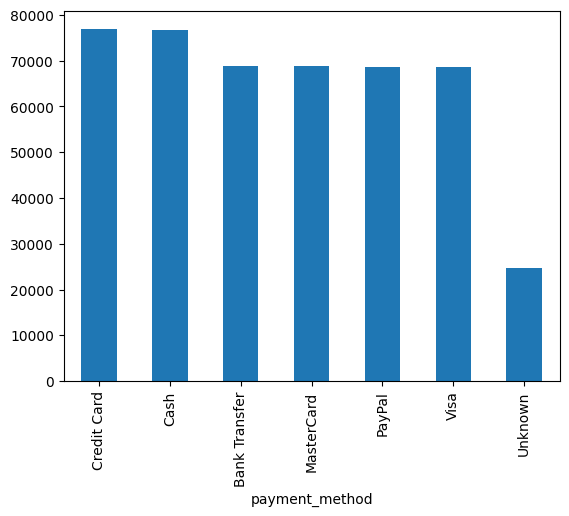

In [185]:
df['payment_method'].value_counts().plot(kind='bar')
plt.show()

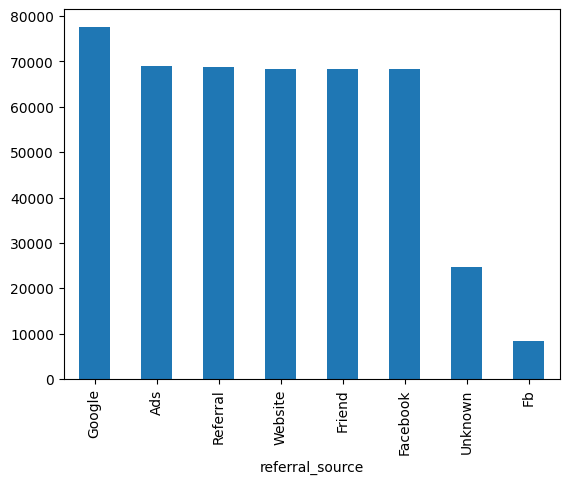

In [186]:
df['referral_source'].value_counts().plot(kind='bar')
plt.show()

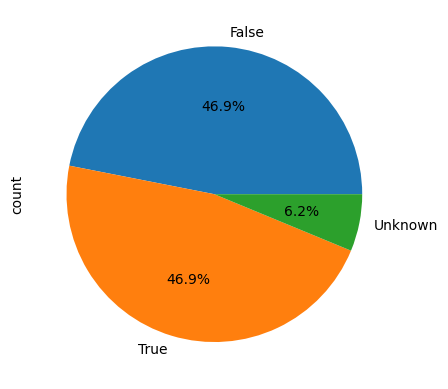

In [188]:
df['premium_customer'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.show()

In [197]:
df.to_csv('customer_final.csv', index=False)

In [199]:
from google.colab import files

files.download('customer_final.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>